# MNIST Anomaly detection - Tutorial notebook

Source: https://benjoe.medium.com/anomaly-detection-using-pytorch-autoencoder-and-mnist-31c5c2186329

### 1. Setting up libraries

In [120]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, losses
from tensorflow.keras.models import Model
from keras.datasets import mnist

import torch
import time

import torch.nn as nn
import seaborn as sns
from collections import defaultdict
from datetime import timedelta

In [121]:
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


### 2. Set up clean and create toy "anomalous" data from x_test

Motivation: Idea is that we will be adding artificial noise to the anom data, specifically the indices 0 - 999 data points from x_train.

In [122]:
# Reduce dimensionality and flatten the images to give single pixel values.
original = x_test.copy()  # save clean copies before noise modifies the view
anom = x_test[:1000].reshape(1000, -1)
clean = x_test[1000:].reshape(x_test[1000:].shape[0], -1)


print(anom.shape)
for i in range(len(anom)):
    # select row from anom
    row = anom[i]
    # iterate through each element in row
    for i in range(len(row)-1):
        # add noise scaled to [0,1] pixel range
        row[i+1] = min(1.0, row[i+1] + random.randint(100, 200) / 255.0)

(1000, 784)


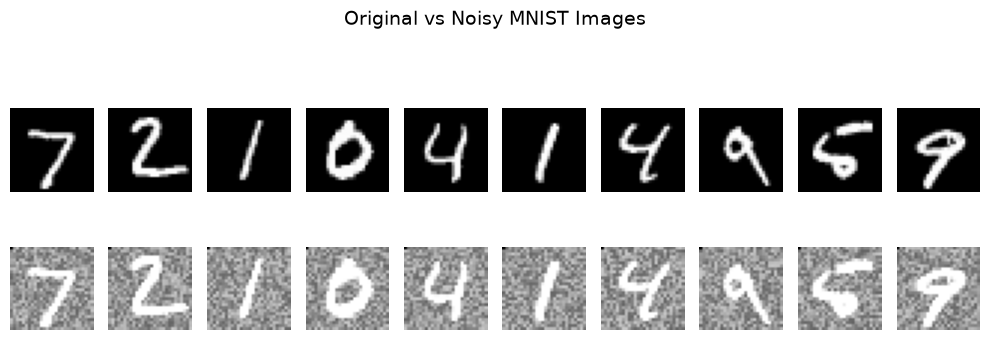

In [123]:
n = 10  # number of examples to display

fig, axes = plt.subplots(2, n, figsize=(10, 4))

for i in range(n):
    axes[0, i].imshow(original[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')

    axes[1, i].imshow(anom[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=12)
axes[1, 0].set_ylabel('Noisy', fontsize=12)

plt.suptitle('Original vs Noisy MNIST Images', fontsize=14)
plt.tight_layout()
plt.show()

### 3. Concatenate, shuffle, and save the dataset

In [124]:
# Convert numpy arrays to DataFrames and attach labels
anom_df = pd.DataFrame(anom)
anom_df['label'] = 1  # anomalous

clean_df = pd.DataFrame(clean)
clean_df['label'] = 0  # clean

# Concatenate, shuffle, and save
an_test = pd.concat([anom_df, clean_df])
an_test = an_test.sample(frac=1).reset_index(drop=True)
an_test.to_csv('anom.csv', index=False)

print(an_test.shape)
print(an_test['label'].value_counts())

(10000, 785)
label
0    9000
1    1000
Name: count, dtype: int64


### 4. Linear compression 

In [125]:
import torch.nn as nn
class AE(nn.Module):
    def __init__(self):
        super(AE, self).__init__()
        self.enc = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )
        self.dec = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.ReLU()
        )
    def forward(self, x):
        encode = self.enc(x)
        decode = self.dec(encode)
        return decode

In [126]:
batch_size = 32
lr = 1e-2         # learning rate
w_d = 1e-5        # weight decay
momentum = 0.9   
epochs = 15

### 5. Training

In [127]:
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Flatten x_train to (60000, 784) and wrap in a DataLoader
x_train_flat = x_train.reshape(len(x_train), -1)
train_tensor = torch.tensor(x_train_flat, dtype=torch.float32)
train_ = DataLoader(train_tensor, batch_size=batch_size, shuffle=True)

model = AE().to(device)
criterion = nn.MSELoss(reduction='mean')
optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=w_d, momentum=momentum)

metrics = defaultdict(list)

model.train()
start = time.time()
for epoch in range(epochs):
    ep_start = time.time()
    running_loss = 0.0
    for bx, data in enumerate(train_):
        data = data.to(device)
        sample = model(data)
        loss = criterion(data, sample)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    epoch_loss = running_loss / len(train_)
    metrics['train_loss'].append(epoch_loss)
    ep_end = time.time()
    print('-----------------------------------------------')
    print('[EPOCH] {}/{}\n[LOSS] {:.6f}'.format(epoch+1, epochs, epoch_loss))
    print('Epoch Complete in {}'.format(timedelta(seconds=ep_end-ep_start)))
end = time.time()
print('-----------------------------------------------')
print('[System Complete: {}]'.format(timedelta(seconds=end-start)))

-----------------------------------------------
[EPOCH] 1/15
[LOSS] 0.093666
Epoch Complete in 0:00:10.468692
-----------------------------------------------
[EPOCH] 2/15
[LOSS] 0.084652
Epoch Complete in 0:00:09.129977
-----------------------------------------------
[EPOCH] 3/15
[LOSS] 0.084556
Epoch Complete in 0:00:09.370201
-----------------------------------------------
[EPOCH] 4/15
[LOSS] 0.084556
Epoch Complete in 0:00:13.604029
-----------------------------------------------
[EPOCH] 5/15
[LOSS] 0.084556
Epoch Complete in 0:00:27.842828
-----------------------------------------------
[EPOCH] 6/15
[LOSS] 0.084556
Epoch Complete in 0:00:19.052522
-----------------------------------------------
[EPOCH] 7/15
[LOSS] 0.084556
Epoch Complete in 0:00:13.773668
-----------------------------------------------
[EPOCH] 8/15
[LOSS] 0.084556
Epoch Complete in 0:00:12.719388
-----------------------------------------------
[EPOCH] 9/15
[LOSS] 0.084556
Epoch Complete in 0:00:12.678976
----------

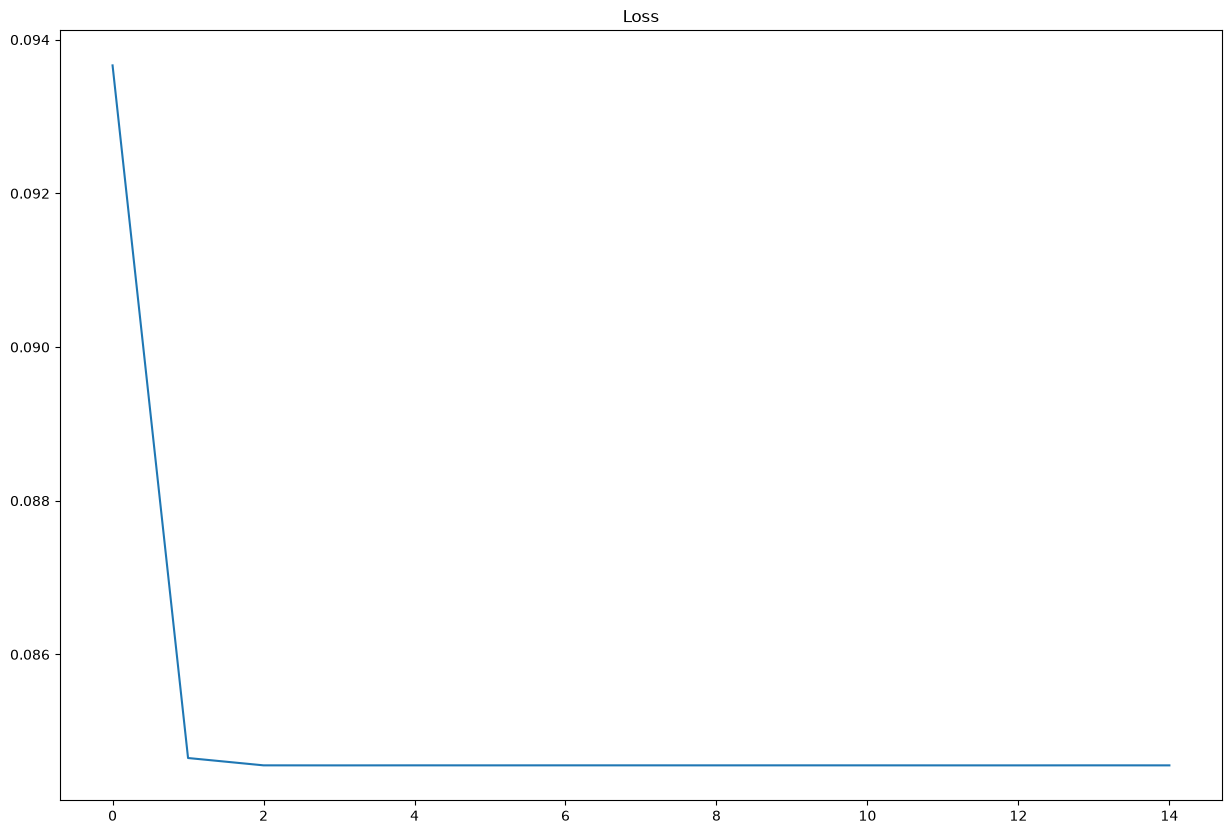

In [128]:
_, ax = plt.subplots(1,1,figsize=(15,10))
ax.set_title('Loss')
ax.plot(metrics['train_loss'])